In [1]:
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib as mpl
from statannot import add_stat_annotation

In [2]:
data_=pd.read_csv("./2024_09_16_seqs/seqs/Table S13.csv",skiprows=2) 
print(len(data_))
print(data_[np.any(pd.isnull(data_),axis=1)])

29531
             EVENT               VARIANT  \
1432  HsaEX0000641  ABI1-HsaEX0000641-WT   

                                                  OLIGO UPINT VAR_SEQ DOINT  \
1432  TTGAGTAACTGTAAATGTAAACCTGTCCTATCGGATATAACTTACC...   NaN     NaN   NaN   

      VAR_LEN Library  
1432       15      T0  


In [3]:
data=data_.dropna()

In [4]:

context=10000
i=2
event, variant, oligo, upint, var_seq, doint = data.iloc[i].values[0:6]
seq=upint+var_seq+doint
#if False:
#    out=scoreseq(seq,context=context)

In [5]:
data2=pd.read_excel("./2024_09_16_seqs/events/Table S1.xlsx",skiprows=2) #event-tier information
print(len(data2))
display(data2.head())
data2_dict={}
for i in range(len(data2)):
    key,value=data2.iloc[i].values
    data2_dict[key]=value

234


,EVENT,TIER
0,HsaEX1026281,CR
1,HsaEX0073335,CR
2,HsaEX0067917,CR
3,HsaEX0037042,CR
4,HsaEX0043902,CR


In [6]:
data_subset=pd.read_excel("./2024_09_16_seqs/events/Table S2.xlsx",skiprows=2)
print(len(data_subset))
data_subset=data_subset[data_subset["EVENT"]!="HsaEX0002213"]
print(len(data_subset))
data_subset=data_subset[np.any(data_subset[["T1","T2","T3","T4"]].values=="yes",axis=1)] #events used in T1,T2,T3 or T4, removing the event HsaEX0002213 that was removed in the analysis
print(len(data_subset))
data_subset.head()

43
42
42


,EVENT,TIER,T0,T1,T2,T3,T4
0,HsaEX1045708,CR,yes,yes,yes,no,no
1,HsaEX1011407,CR,yes,yes,yes,no,no
2,HsaEX0043902,CR,yes,yes,yes,no,no
3,HsaEX1038166,CS,yes,no,no,yes,yes
4,HsaEX6024969,CS,yes,yes,yes,yes,yes


In [7]:
data_subset[~data_subset["EVENT"].isin(data2["EVENT"])]

,EVENT,TIER,T0,T1,T2,T3,T4
11,HsaEX7108093,CS,no,no,no,yes,yes


In [8]:
tier_dict={"CS":"CS","CR":"CR","LS":"LS","HS":"HS","NonResponding":"NR","Others":"O"}

titles ['CS', 'CR', 'LS', 'HS', 'NR']
HsaEX0000641-ABI1-HsaEX0000641-WT 133 124 93 15 25


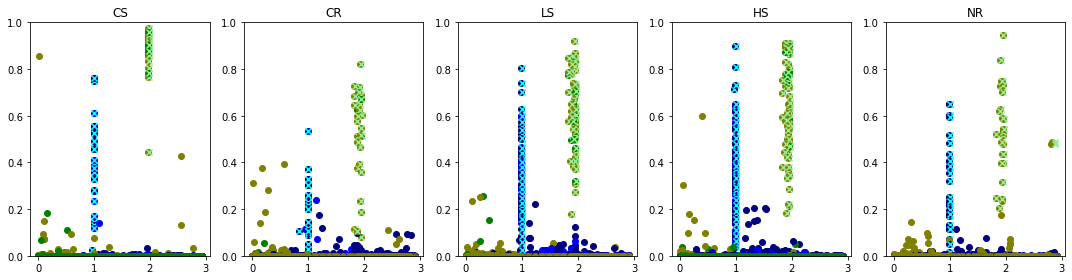

In [9]:

scoring=open("spliceAI/spliceAI_scoresall_context=10000.csv", "r")
scores={"CS":[],"CR":[],"LS":[],"HS":[],"NR":[],"O":[]}
data_for_df={"tier":[],"insubset":[],"accmax":[],"donmax":[]}
done=[]
plot=True
fig,axes=plt.subplots(1,5,figsize=(15,4))
titles=list(scores.keys())[0:5]
print("titles", titles)
for line in scoring.readlines():
    #print(line)
    event, variant, acc, don, nothing=line.strip().split(";")
    if variant.endswith("WT"):
        if event=="HsaEX7108093":
            tier="CS" #from Table S2
        else:
            tier=data2_dict[event]
        
        tier=tier_dict[tier]
        #print("tier", tier)
        #if tier in ["LS","HS"]:
        row_=data[(data["EVENT"]==event)&(data["VARIANT"]==variant)]
        row=row_.iloc[0]
        nupint=len(row["UPINT"])
        nex=len(row["VAR_SEQ"])
        ndint=len(row["DOINT"])
        event_var=event+"-"+variant
        if event_var in done:
            continue
        if event in data_subset["EVENT"].values:
            insubset=True
        else:
            insubset=False
            
        #xvals=range(nupint+nex+ndint)
        xvals1=np.arange(0,nupint)/nupint
        xvals2=np.arange(0,nex)/nex
        xvals3=np.arange(0,ndint)/ndint

        xvals=np.concatenate((xvals1,xvals1[-1]+xvals2,xvals1[-1]+xvals2[-1]+xvals3))
        #3'ss region
        acc=np.array(list(map(float,acc.split(","))))
        if len(xvals)!=len(acc):
            print(event_var, len(xvals), len(acc), nupint, nex, ndint)
            continue
        w=93
        if nupint<w:
            print("nuptint < w!!!")
        init3=nupint-w
        end3=nupint+3
        score3idx=np.argmax(acc[init3:end3])
        score3val=acc[init3+score3idx]
        #normalise score3idx
        if score3idx>=w:
            score3idx=(score3idx-w)/nex + 1
        else:
            score3idx=init3/nupint + score3idx/nupint
        
        
        #5'ss region
        don=np.array(list(map(float,don.split(","))))
        if len(xvals)!=len(don):
            print(event_var,len(xvals), len(don))
        w=3
        if nex<w:
            print("nex<w!!")
        init5=nupint+nex-w
        end5=nupint+nex+25
        score5idx=np.argmax(don[init5:end5])
        score5val=don[init5+score5idx]
        #normalise score5idx
        if score5idx>=w:
            score5idx=(score5idx-w)/ndint + 2
        else:
            score5idx=1 + (nex-w)/nex + score5idx/nex 
        if tier!="O":
            ax=axes[titles.index(tier)]
            ax.set_title(tier)
            if insubset:
                color_a="blue"
                color_d="green"
            else:
                color_a="navy"
                color_d="olive"
            ax.scatter(xvals,acc,color=color_a)
            ax.scatter(score3idx,score3val,color="cyan",marker="x")
            ax.scatter(xvals,don,color=color_d)
            ax.scatter(score5idx,score5val,color="lightgreen",marker="x")
            ax.set_ylim(0,1)
            
        
        data_for_df["tier"].append(tier)
        data_for_df["insubset"].append(insubset)
        data_for_df["accmax"].append(score3val)
        data_for_df["donmax"].append(score5val)
        #data_for_df["event_var"].append(event_var)
        done.append(event_var)
plt.tight_layout()
plt.show()
     

In [10]:
df=pd.DataFrame(data_for_df)
df.columns=["Tier","Library subset","Acceptor","Donor"]
df

,Tier,Library subset,Acceptor,Donor
0,NR,False,0.604363,0.477087
1,CR,False,0.327312,0.189409
2,CS,True,0.761872,0.960156
3,CR,False,0.371442,0.603129
4,CS,False,0.467144,0.856656
...,...,...,...,...
230,HS,False,0.159001,0.382084
231,LS,False,0.158594,0.179816
232,LS,False,0.026366,0.405796
233,HS,True,0.386814,0.788926


In [11]:
df2=df.dropna()
len(df2)

235

In [12]:
df2["Tier"][np.isinf(df2["Donor"].values)]

Series([], Name: Tier, dtype: object)

In [13]:
melted=pd.melt(df,id_vars=["Tier","Library subset"])
melted

,Tier,Library subset,variable,value
0,NR,False,Acceptor,0.604363
1,CR,False,Acceptor,0.327312
2,CS,True,Acceptor,0.761872
3,CR,False,Acceptor,0.371442
4,CS,False,Acceptor,0.467144
...,...,...,...,...
465,HS,False,Donor,0.382084
466,LS,False,Donor,0.179816
467,LS,False,Donor,0.405796
468,HS,True,Donor,0.788926


In [14]:
subdf_=df2[df2["Tier"].isin(["LS","HS"])]
subdf_=subdf_.rename(columns={"Tier":"TIER"})
subdf_.head()

,TIER,Library subset,Acceptor,Donor
9,HS,False,0.205388,0.630130
12,HS,False,0.228765,0.338337
14,LS,False,0.362376,0.634992
15,HS,False,0.321757,0.212719
17,LS,True,0.382284,0.416213


In [15]:
from scipy.stats import ks_2samp
from scipy.stats import ranksums
from scipy.stats import mannwhitneyu #mannshitneyu is equivalent to ranksums but still, try

In [17]:
mpl.rcParams["pdf.fonttype"]=42

/Users/rosamartinezcorral/miniconda3/envs/torchEnv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/rosamartinezcorral/miniconda3/envs/torchEnv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/rosamartinezcorral/miniconda3/envs/torchEnv/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
No artists with labels found to put in legen

U MannwhitneyuResult(statistic=2612.0, pvalue=0.9363022678675704)
LS v.s. HS: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=9.363e-01 U_stat=2.612e+03


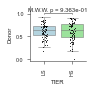

/Users/rosamartinezcorral/miniconda3/envs/torchEnv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/rosamartinezcorral/miniconda3/envs/torchEnv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/rosamartinezcorral/miniconda3/envs/torchEnv/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
No artists with labels found to put in legen

U MannwhitneyuResult(statistic=32.0, pvalue=0.0009058485425290966)
LS v.s. HS: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=9.058e-04 U_stat=3.200e+01


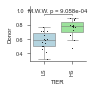

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


U MannwhitneyuResult(statistic=2612.0, pvalue=0.9363022678675704)
LS v.s. HS: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=9.363e-01 U_stat=2.612e+03


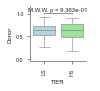

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


U MannwhitneyuResult(statistic=32.0, pvalue=0.0009058485425290966)
LS v.s. HS: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=9.058e-04 U_stat=3.200e+01


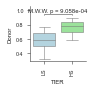

/Users/rosamartinezcorral/miniconda3/envs/torchEnv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/rosamartinezcorral/miniconda3/envs/torchEnv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/rosamartinezcorral/miniconda3/envs/torchEnv/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
No artists with labels found to put in legen

U MannwhitneyuResult(statistic=2451.0, pvalue=0.575869785173271)
LS v.s. HS: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=5.759e-01 U_stat=2.451e+03


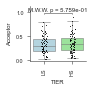

/Users/rosamartinezcorral/miniconda3/envs/torchEnv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/rosamartinezcorral/miniconda3/envs/torchEnv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/rosamartinezcorral/miniconda3/envs/torchEnv/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
No artists with labels found to put in legen

U MannwhitneyuResult(statistic=115.0, pvalue=0.9338864180775845)
LS v.s. HS: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=9.339e-01 U_stat=1.150e+02


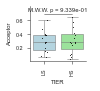

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


U MannwhitneyuResult(statistic=2451.0, pvalue=0.575869785173271)
LS v.s. HS: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=5.759e-01 U_stat=2.451e+03


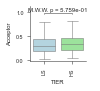

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


U MannwhitneyuResult(statistic=115.0, pvalue=0.9338864180775845)
LS v.s. HS: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=9.339e-01 U_stat=1.150e+02


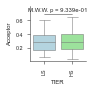

In [21]:
for Score in ["Donor","Acceptor"]:
    for i,dots in enumerate([True,False]):
        for s,subdf in enumerate([subdf_,subdf_[subdf_["Library subset"]==True]]):
            subset=["all","subset"][s]
            basename=f"{Score}_dots={dots}_{subset}"

            vals_LS=subdf[(subdf["TIER"]=="LS")][Score]
            vals_HS=subdf[subdf["TIER"]=="HS"][Score]
            print("U",mannwhitneyu(vals_LS,vals_HS,alternative="two-sided"))

            sns.set(style="ticks", context="talk", font_scale=.33, font="Arial",rc={'figure.figsize':(1,1)}) #rc={'figure.figsize':(1,1)})



            g = sns.boxplot(data = subdf, x = "TIER", y = Score, order = ['LS', 'HS'],linewidth = .5,palette = {"LS":'lightblue', "HS":'lightgreen'}, flierprops = dict(marker='o', markersize=0))
            if i==0: #add individual dots
                g = sns.stripplot(data = subdf , x = "TIER", y = Score, order = ['LS', 'HS'], s = 1, dodge = False, jitter = True,color="black")
            #elif i==1:
            #    g = sns.stripplot(data = subdf , x = "TIER", y = Score, order = ['LS', 'HS'], s = 1, dodge = False, jitter = True, palette = {"LS":'blue', "HS":'green'})

            add_stat_annotation(g, data = subdf, x = "TIER", y = Score, order = ['LS', 'HS'], box_pairs=[(("LS"), ("HS")),],linewidth = .5, test='Mann-Whitney', text_format='full',loc='inside', verbose=2, fontsize = 6)



            g.patch.set_alpha(0)
            g.spines[['left', 'bottom']].set_linewidth(.5)
            g.spines[['right', 'top']].set_linewidth(0)
            g.xaxis.set_tick_params(width=0.5, length=3)
            g.yaxis.set_tick_params(width=0.5, length=3)

            plt.legend(loc='upper left', bbox_to_anchor=(1, 1), framealpha=0)
            plt.xticks(rotation=90)
            plt.savefig(f"spliceAI_{basename}.pdf", bbox_inches='tight', dpi=500, transparent=True)
            plt.show()

In [50]:
np.any(pd.isnull(melted))

False

In [51]:
import seaborn as sns
from scipy.stats import ks_2samp
from scipy.stats import ranksums
from scipy.stats import mannwhitneyu #mannshitneyu is equivalent to ranksums but still, try

In [52]:
sample1=np.random.normal(1,0.5,size=100)
sample2=np.random.normal(2,0.5,size=100)
ks_2samp(sample1,sample2,alternative="greater"),ks_2samp(sample1,sample2,alternative="less"),ks_2samp(sample1,sample2,alternative="two-sided")

(KstestResult(statistic=0.7, pvalue=4.524444233879144e-24, statistic_location=1.5813415782311266, statistic_sign=1),
 KstestResult(statistic=0.0, pvalue=1.0, statistic_location=3.0868130304119856, statistic_sign=-1),
 KstestResult(statistic=0.7, pvalue=9.048888467758296e-24, statistic_location=1.5813415782311266, statistic_sign=1))

In [53]:
ranksums(sample1,sample2,alternative="less"),ranksums(sample1,sample2,alternative="two-sided")

(RanksumsResult(statistic=-10.425940381367088, pvalue=9.439126548413723e-26),
 RanksumsResult(statistic=-10.425940381367088, pvalue=1.8878253096827446e-25))

In [54]:
mannwhitneyu(sample1,sample2,alternative="less"),mannwhitneyu(sample1,sample2,alternative="two-sided")

(MannwhitneyuResult(statistic=733.0, pvalue=9.561218128204022e-26),
 MannwhitneyuResult(statistic=733.0, pvalue=1.9122436256408045e-25))

In [41]:
LS_ls=melted[(melted["Library subset"]==True)&(melted["variable"]=="Donor")&(melted["Tier"]=="LS")]["value"].values
LS_ls_df2=df2[(df2["Library subset"]==True)&(df2["Tier"]=="LS")]["Donor"].values
print(LS_ls)
print(LS_ls_df2)

HS_ls=melted[(melted["Library subset"]==True)&(melted["variable"]=="Donor")&(melted["Tier"]=="HS")]["value"].values
HS_ls_df2=df2[(df2["Library subset"]==True)&(df2["Tier"]=="HS")]["Donor"].values
print(HS_ls)
print(HS_ls_df2)

[0.41621333 0.7173988  0.60018617 0.55212355 0.71121347 0.46089253
 0.53551495 0.6033023  0.70682734 0.65197074 0.31980735 0.5770634
 0.49407452 0.77352357 0.50066155]
[0.41621333 0.7173988  0.60018617 0.55212355 0.71121347 0.46089253
 0.53551495 0.6033023  0.70682734 0.65197074 0.31980735 0.5770634
 0.49407452 0.77352357 0.50066155]
[0.7912267  0.6490619  0.7730631  0.77892053 0.87369585 0.4683072
 0.89841443 0.6495255  0.8983313  0.78610635 0.73147464 0.5847338
 0.8719307  0.7701498  0.78892565]
[0.7912267  0.6490619  0.7730631  0.77892053 0.87369585 0.4683072
 0.89841443 0.6495255  0.8983313  0.78610635 0.73147464 0.5847338
 0.8719307  0.7701498  0.78892565]


s=0 235
Acceptor, KS All KstestResult(statistic=0.07891182712714644, pvalue=0.5927820313732248, statistic_location=0.23417564, statistic_sign=1)
Acceptor, KS All KstestResult(statistic=0.07891182712714644, pvalue=0.9568774834799966, statistic_location=0.23417564, statistic_sign=1)
Acceptor, WR All RanksumsResult(statistic=-0.5614257679626621, pvalue=0.2872536609219587)
Acceptor, WR All RanksumsResult(statistic=-0.5614257679626621, pvalue=0.5745073218439174)
Acceptor, U All MannwhitneyuResult(statistic=2451.0, pvalue=0.2879348925866355)
Acceptor, U All MannwhitneyuResult(statistic=2451.0, pvalue=0.575869785173271)
Donor All KstestResult(statistic=0.12290179432760949, pvalue=0.296815680182198, statistic_location=0.8677629, statistic_sign=1)
Donor All KstestResult(statistic=0.12290179432760949, pvalue=0.5794898733862541, statistic_location=0.8677629, statistic_sign=1)
Donor, WR All RanksumsResult(statistic=0.0819162152543386, pvalue=0.5326433300666076)
Donor, WR All RanksumsResult(statist

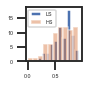

s=1 42
Acceptor, KS Library subset KstestResult(statistic=0.13333333333333333, pvalue=0.7720588235294117, statistic_location=0.40231228, statistic_sign=1)
Acceptor, KS Library subset KstestResult(statistic=0.13333333333333333, pvalue=0.9997887537139585, statistic_location=0.40231228, statistic_sign=1)
Acceptor, WR Library subset RanksumsResult(statistic=0.10369516947304253, pvalue=0.5412943699039795)
Acceptor, WR Library subset RanksumsResult(statistic=0.10369516947304253, pvalue=0.917411260192041)
Acceptor, U Library subset MannwhitneyuResult(statistic=115.0, pvalue=0.5495142532917794)
Acceptor, U Library subset MannwhitneyuResult(statistic=115.0, pvalue=0.9338864180775845)
Donor Library subset KstestResult(statistic=0.6666666666666666, pvalue=0.0009186969982501007, statistic_location=0.7173988, statistic_sign=1)
Donor Library subset KstestResult(statistic=0.6666666666666666, pvalue=0.0018373939965002021, statistic_location=0.7173988, statistic_sign=1)
Donor, WR Library subset Ranksum

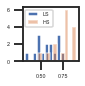

In [46]:
for s,subdf in enumerate([melted,melted[melted["Library subset"]==True]]):
    acc=subdf[subdf["variable"]=="Acceptor"]
    print("s=%d"%s, len(acc))
    LSa=acc[acc["Tier"]=="LS"]["value"].values
    HSa=acc[acc["Tier"]=="HS"]["value"].values
    
    
    
    test=ks_2samp(LSa,HSa,alternative="greater") #HS>LS--> cumulative of HS<LS --> we want to test the null that LS<HS
    print("Acceptor, KS",["All","Library subset"][s],test )
    test=ks_2samp(LSa,HSa,alternative="two-sided") #HS>LS--> cumulative of HS<LS --> we want to test the null that LS<HS
    print("Acceptor, KS",["All","Library subset"][s],test )
    
    test=ranksums(LSa,HSa,alternative="less") 
    print("Acceptor, WR",["All","Library subset"][s],test )
    test=ranksums(LSa,HSa,alternative="two-sided") 
    print("Acceptor, WR",["All","Library subset"][s],test )
    
    test=mannwhitneyu(LSa,HSa,alternative="less") 
    print("Acceptor, U",["All","Library subset"][s],test )
    test=mannwhitneyu(LSa,HSa,alternative="two-sided") 
    print("Acceptor, U",["All","Library subset"][s],test )
    
    don=subdf[subdf["variable"]=="Donor"]
    LSd=don[don["Tier"]=="LS"]["value"].values
    HSd=don[don["Tier"]=="HS"]["value"].values
    
   
    
    test=ks_2samp(LSd,HSd,alternative="greater")
    print("Donor",["All","Library subset"][s],test )
    test=ks_2samp(LSd,HSd,alternative="two-sided")
    print("Donor",["All","Library subset"][s],test )
    
    test=ranksums(LSd,HSd,alternative="less")
    print("Donor, WR",["All","Library subset"][s],test )
    test=ranksums(LSd,HSd,alternative="two-sided")
    print("Donor, WR",["All","Library subset"][s],test )
    
    test=mannwhitneyu(LSd,HSd,alternative="less")
    print("Donor, U",["All","Library subset"][s],test )
    test=mannwhitneyu(LSd,HSd,alternative="two-sided")
    print("Donor, U",["All","Library subset"][s],test )
    
    plt.hist(LSd,label="LS")
    plt.hist(HSd,label="HS",alpha=0.5)
    plt.legend()
    plt.show()
    
   # test=ks_2samp(LSd+LSa,HSd+HSa,alternative="greater")
   # print("Acceptor+Donor",["All","Library subset"][s],test )
    

/Users/rosamartinezcorral/miniconda3/envs/torchEnv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/rosamartinezcorral/miniconda3/envs/torchEnv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/rosamartinezcorral/miniconda3/envs/torchEnv/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/rosamartinezcorral/miniconda3/envs/torchEnv/lib/python3.10/site-packages/seaborn/_ol

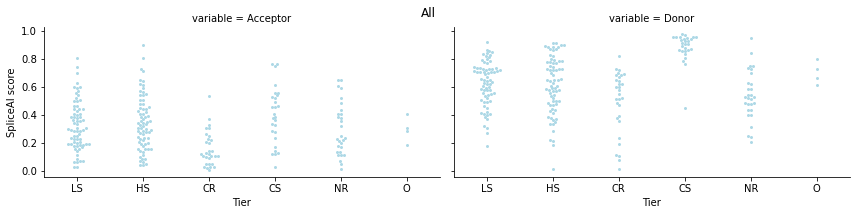

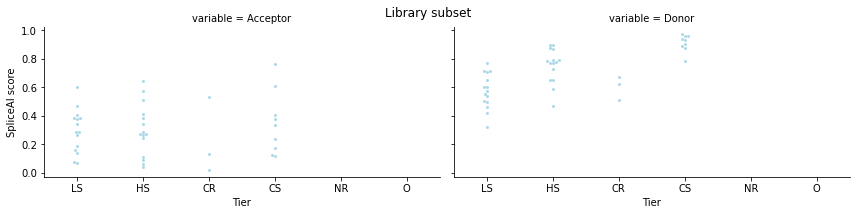

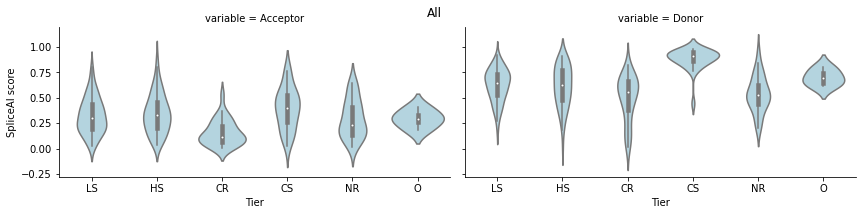

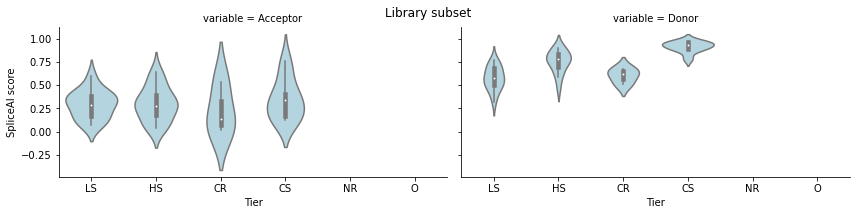

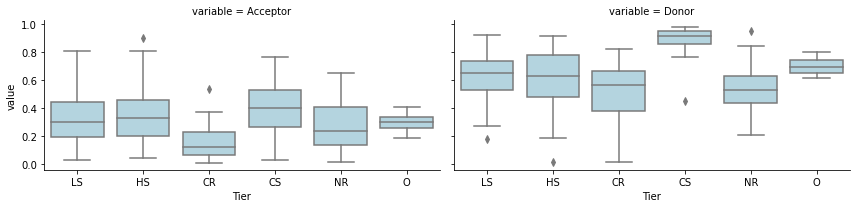

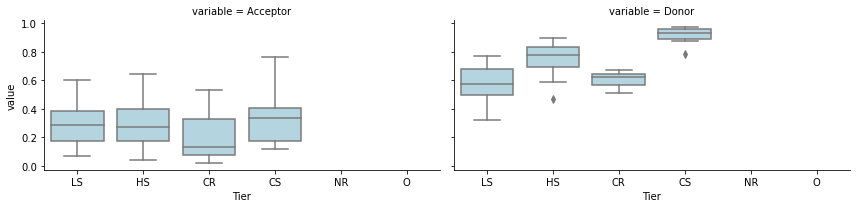

In [55]:
for kind in ["swarm","violin","box"]:
    for s,subdf in enumerate([melted,melted[melted["Library subset"]==True]]):
        if kind == "box":
            out=sns.catplot(data=subdf,x="Tier",order=["LS","HS","CR","CS","NR","O"],y="value",kind=kind,height=3,aspect=2,col="variable",color="lightblue")
        else:
            out=sns.catplot(data=subdf,x="Tier",order=["LS","HS","CR","CS","NR","O"],y="value",kind=kind,size=3,height=3,aspect=2,col="variable",color="lightblue")
            out.set_axis_labels("Tier","SpliceAI score")
            #out.legend.remove()
            #out.add_legend(title="")
            out.fig.suptitle(["All", "Library subset"][s])

In [ ]:
OLD

sizes do not match HsaEX0000641 ABI1-HsaEX0000641-WT
sizes do not match HsaEX0000641 ABI1-HsaEX0000641-WT


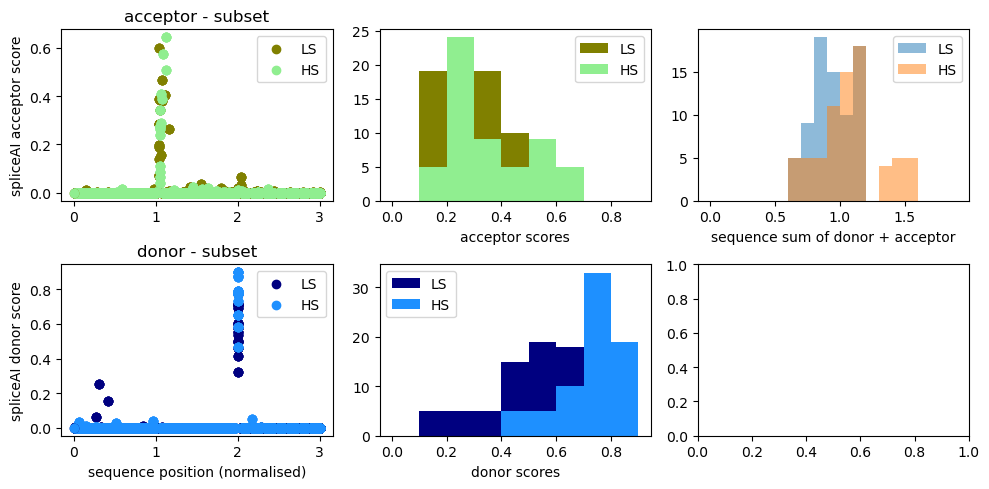

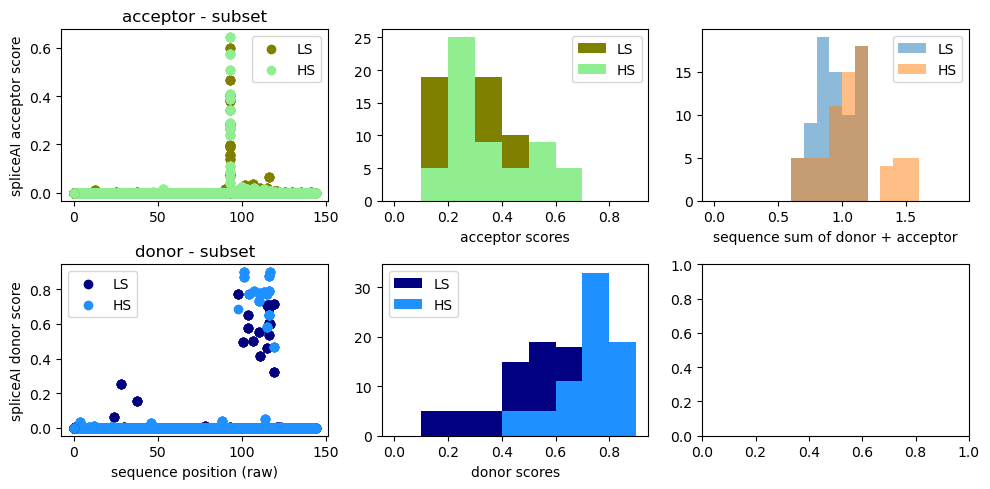

sizes do not match HsaEX0000641 ABI1-HsaEX0000641-WT
sizes do not match HsaEX0000641 ABI1-HsaEX0000641-WT


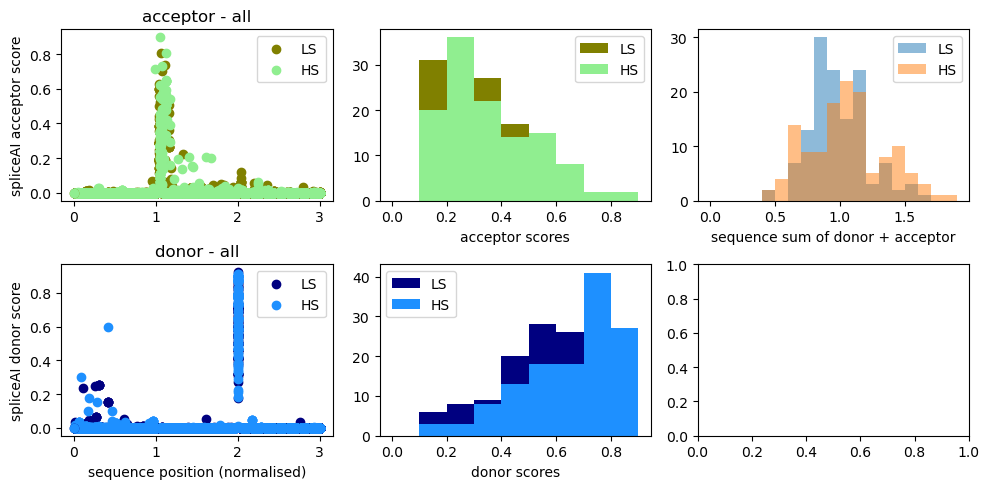

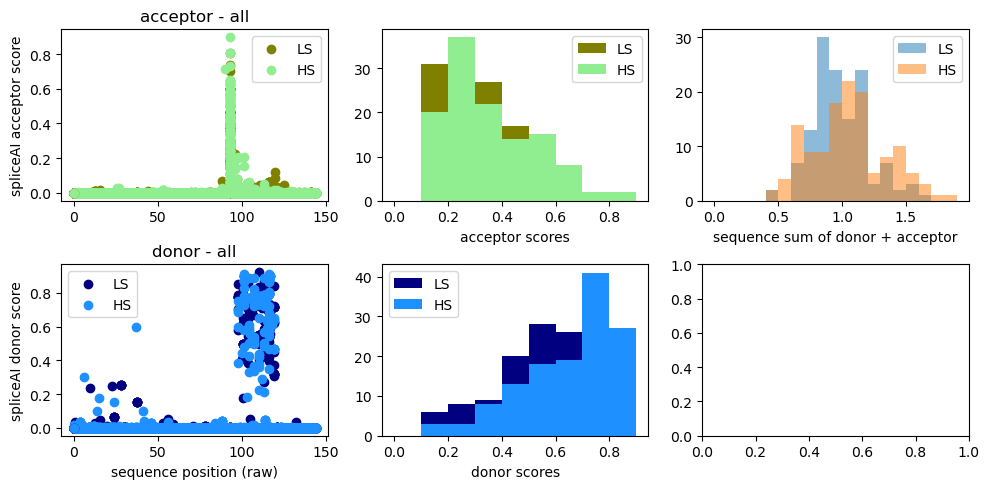

In [14]:
for s,subset in enumerate([True,False]):
    title=["subset","all"][s]
    for n,norm in enumerate([True,False]):
        label=["normalised","raw"][n]
        fig,axes=plt.subplots(2,3,figsize=(10,5))
        colors={"LS":["olive","navy"],"HS":["lightgreen","dodgerblue"]}
        ax0=axes[0][0]
        ax1=axes[1][0]
        ax2=axes[0][1]
        ax3=axes[1][1]
        ax4=axes[0][2]
        acc_array=[]
        don_array=[]
        acc_don_array=[]
        for t,tier in enumerate(["LS","HS"]):
            allacc=[]
            alldon=[]
            acc_plus_don=[]
            for i in range(len(scores[tier])):
                acc,don,nupint,nex,ndint, event, variant,insubset=scores[tier][i]
                if subset:
                    if insubset:
                        plot=True
                    else:
                        plot=False
                else:
                    plot=True #plot all in this case
                if plot:
                    acc=np.array(list(map(float,acc.split(","))))
                    don=np.array(list(map(float,don.split(","))))
                    if norm:
                        xvals1=np.arange(1,nupint+1)/nupint
                        xvals2=np.arange(1,nex+1)/nex
                        xvals3=np.arange(1,ndint+1)/ndint
                       
                        xvals=np.concatenate((xvals1,xvals1[-1]+xvals2,xvals1[-1]+xvals2[-1]+xvals3))
                        offset=0.01*t
                    else:
                        xvals=np.arange(len(acc))
                        offset=0.1*t
                    if len(xvals)==len(acc):
                        ax0.scatter(xvals+offset,acc,color=colors[tier][0])
                        allacc.extend(list(acc))
                    else:
                        print("sizes do not match", event, variant)
                    if len(xvals)==len(don):
                        ax1.scatter(xvals+offset,don,color=colors[tier][1])
                        alldon.extend(list(don))
                    else:
                        print("sizes do not match", event, variant)
                    acc_plus_don.append(np.sum(acc)+np.sum(don))
            allacc=np.array(allacc)
            alldon=np.array(alldon)
            acc_array.append(allacc)
            don_array.append(alldon)
            acc_don_array.append(acc_plus_don)
            allacc=allacc[allacc>0.1]
            alldon=alldon[alldon>0.1]
            ax=ax2
            ax.hist(allacc,color=colors[tier][0],bins=np.arange(0,1,0.1),label=tier)
            ax=ax3
            ax.hist(alldon,color=colors[tier][1],bins=np.arange(0,1,0.1),label=tier)
            ax=ax4
            ax.hist(acc_plus_don,bins=np.arange(0,2,0.1),label=tier,alpha=0.5)
        #kstest_acc_ones=ks_2samp(*acc_array,alternative="greater") #HS>LS--> cumulative of HS<LS --> we want to test the null that LS<HS
        #kstest_don_ones=ks_2samp(*don_array,alternative="greater")
        #kstest_acc_twos=ks_2samp(*acc_array,alternative="two-sided") 
        #kstest_don_twos=ks_2samp(*don_array,alternative="two-sided")
        
        ax0.set_title("acceptor - %s"%title)
        ax1.set_title("donor - %s"%title)
        ax1.set_xlabel("sequence position (%s)"%label)
        ax0.set_ylabel("spliceAI acceptor score")
        ax1.set_ylabel("spliceAI donor score")
        for tier in ["LS","HS"]:
            ax0.scatter(0,0,color=colors[tier][0],label=tier)
            ax1.scatter(0,0,color=colors[tier][1],label=tier)
        for ax in [ax2,ax3,ax4]:
            ax.legend()
        ax2.set_xlabel("acceptor scores")
        ax3.set_xlabel("donor scores")
        ax4.set_xlabel("sequence sum of donor + acceptor")
        
        ax0.legend()
        ax1.legend()
        plt.tight_layout()
        plt.show()


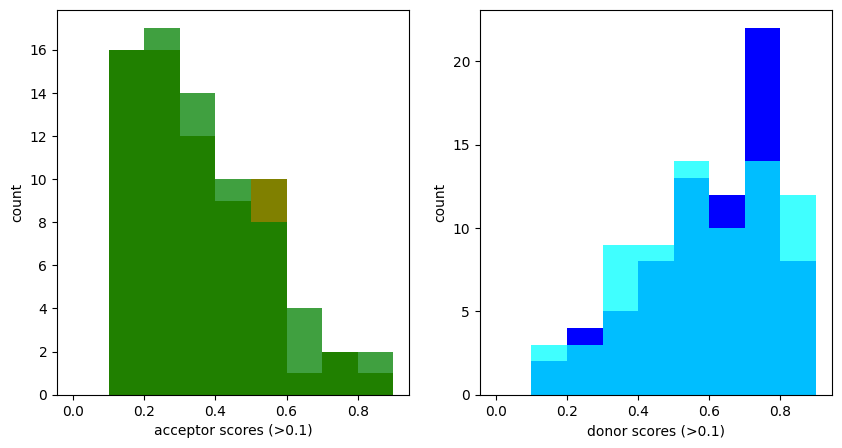

In [106]:
fig,axes=plt.subplots(1,2,figsize=(10,5))
allacc=[]
alldon=[]
for i in range(len(scores["LS"])):
    acc,don=scores["LS"][i][0:2]
    acc=list(map(float,acc.split(",")))
    don=list(map(float,don.split(",")))
    allacc.extend(acc)
    alldon.extend(don)


allacc=[]
alldon=[]

for i in range(len(scores["HS"])):
    acc,don=scores["HS"][i][0:2]
    acc=list(map(float,acc.split(",")))
    don=list(map(float,don.split(",")))
    allacc.extend(acc)
    alldon.extend(don)
allacc=np.array(allacc)
allacc=allacc[allacc>0.1]
alldon=np.array(alldon)
alldon=alldon[alldon>0.1]
ax=axes[0]
ax.hist(allacc,color="green",bins=np.arange(0,1,0.1),alpha=0.75)
ax.set_xlabel("acceptor scores (>0.1)")
ax.set_ylabel("count")
ax=axes[1]
ax.hist(alldon,color="cyan",bins=np.arange(0,1,0.1),alpha=0.75)
ax.set_xlabel("donor scores (>0.1)")
ax.set_ylabel("count")
plt.show()
